# Analyse de Graphes avec GCN et GAT

Ce notebook explore les réseaux de neurones convolutionnels sur graphes (GCN) et les réseaux d'attention sur graphes (GAT) à travers deux études de cas : le club de karaté de Zachary et le dataset CORA de classification de publications scientifiques.

**Auteurs :** Maram Nasr et Skander Haj Mabrouk


**0. Imporation des bibliothèques et librairies essentielles**

In [59]:
import networkx as nx
import numpy as np
import scipy.sparse as sp
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data
from sklearn.linear_model import LogisticRegression

## **1. Club de Karaté et GCN aléatoire**

### **1.1 Chargement et exploration du graphe**

Nous commençons par charger le graphe du club de karaté de Zachary, qui modélise les interactions sociales entre 34 membres d'un club avant sa scission en deux groupes.

In [2]:
# charger les données
G = nx.karate_club_graph()
n = G.number_of_nodes()  # 34 nœuds
print(f"\nGraphe : {n} nœuds, {G.number_of_edges()} arêtes")


Graphe : 34 nœuds, 78 arêtes


In [15]:
# récupérer les labels
true_labels = np.array([G.nodes[i]['club'] for i in G.nodes()])

### **1.2. Calcul des matrices A~ et D~ pour GCN**

Le GCN nécessite une normalisation de la matrice d'adjacence pour stabiliser la propagation.

In [6]:
# calculer la matrice A
A = nx.adjacency_matrix(G).todense()
A = np.array(A, dtype=float)

print(f"Forme de A : {A.shape}")
print(f"Nombre de connexions : {int(A.sum())}")

Forme de A : (34, 34)
Nombre de connexions : 462


In [7]:
# matrice A~ = A + I
# matrice identité
I = np.eye(n)
# A~ = A + I (chaque nœud se connecte à lui-même)
A_tilde = A + I
print(f"Forme de A~ : {A_tilde.shape}")
print(f"Nombre de connexions: {int(A_tilde.sum())}")
# on vérifie que la diagonale contient des 1
print(f"Diagonale de A~ (premiers 10) : {np.diag(A_tilde)[:10]}")

Forme de A~ : (34, 34)
Nombre de connexions: 496
Diagonale de A~ (premiers 10) : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [8]:
# matrice de degré D~
# D~ est une matrice diagonale où D~[i,i] = degré du nœud i dans A~
# le degré = somme de la ligne i dans A~
degrees = A_tilde.sum(axis=1)  # on fait la somme par ligne
degrees = np.array(degrees).flatten()  # on a besoin d'un tableau 1D
D_tilde = np.diag(degrees)  # on crée une matrice diagonale à partir des degrés
print(f"Forme de D~ : {D_tilde.shape}")
print(f"\nDegrés des premiers 10 nœuds:")
for i in range(10):
    print(f"  Nœud {i} : degré = {int(D_tilde[i,i])}")

Forme de D~ : (34, 34)

Degrés des premiers 10 nœuds:
  Nœud 0 : degré = 43
  Nœud 1 : degré = 30
  Nœud 2 : degré = 34
  Nœud 3 : degré = 19
  Nœud 4 : degré = 9
  Nœud 5 : degré = 15
  Nœud 6 : degré = 14
  Nœud 7 : degré = 14
  Nœud 8 : degré = 18
  Nœud 9 : degré = 4


In [9]:
# matrice D~^(-1/2) (inverse de la racine carrée)
# D~^(-1/2) : chaque élément diagonal devient 1/sqrt(degré)
D_tilde_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D_tilde)))
print(f"Forme de D~^(-1/2) : {D_tilde_inv_sqrt.shape}")
print(f"\nPremiers éléments diagonaux de D~^(-1/2) :")
for i in range(10):
    degree = D_tilde[i,i]
    inv_sqrt = D_tilde_inv_sqrt[i,i]
    print(f"  Nœud {i} : degré={int(degree)} → 1/√{int(degree)} = {inv_sqrt:.4f}")

Forme de D~^(-1/2) : (34, 34)

Premiers éléments diagonaux de D~^(-1/2) :
  Nœud 0 : degré=43 → 1/√43 = 0.1525
  Nœud 1 : degré=30 → 1/√30 = 0.1826
  Nœud 2 : degré=34 → 1/√34 = 0.1715
  Nœud 3 : degré=19 → 1/√19 = 0.2294
  Nœud 4 : degré=9 → 1/√9 = 0.3333
  Nœud 5 : degré=15 → 1/√15 = 0.2582
  Nœud 6 : degré=14 → 1/√14 = 0.2673
  Nœud 7 : degré=14 → 1/√14 = 0.2673
  Nœud 8 : degré=18 → 1/√18 = 0.2357
  Nœud 9 : degré=4 → 1/√4 = 0.5000


In [10]:
# matrice normalisée A_norm = D~^(-1/2) A~ D~^(-1/2)
# normalisation symétrique 
A_norm = D_tilde_inv_sqrt @ A_tilde @ D_tilde_inv_sqrt
print(f"Forme de A_norm : {A_norm.shape}")
print(f"Somme des éléments : {A_norm.sum():.2f}")
# on vérifie la normalisation : chaque ligne devrait avoir une somme raisonnable
print(f"\nSommes des premières lignes de A_norm :")
for i in range(10):
    print(f"  Ligne {i} : somme = {A_norm[i].sum():.4f}")

Forme de A_norm : (34, 34)
Somme des éléments : 28.88

Sommes des premières lignes de A_norm :
  Ligne 0 : somme = 1.9015
  Ligne 1 : somme = 1.3776
  Ligne 2 : somme = 1.3348
  Ligne 3 : somme = 1.0552
  Ligne 4 : somme = 0.7751
  Ligne 5 : somme = 1.0808
  Ligne 6 : somme = 1.0200
  Ligne 7 : somme = 0.7154
  Ligne 8 : somme = 0.7816
  Ligne 9 : somme = 0.4786


### **1.3. GCN à 3 couches avec poids aléatoires**

Nous implémentons un GCN à 3 couches (34 → 16 → 8 → 2) avec des matrices de poids orthogonales tirées aléatoirement, sans entraînement. La matrice identité sert d'attributs initiaux pour les nœuds.

In [19]:
# définir l'architecture du GCN
# architecture : 34 → 16 → 8 → 2
input_dim = n  # 34 (dimension de X, matrice identité)
hidden_dim1 = 16  # première couche cachée
hidden_dim2 = 8   # deuxième couche cachée
output_dim = 2    # 2 classes (Mr. Hi vs Officer)

### **1.4. Calcul des représentations en 2D et 3D**

Nous extrayons les représentations apprises par le GCN aléatoire en sortie, d'abord en 2 dimensions puis en 3 dimensions, afin de visualiser comment le réseau projette les nœuds dans des espaces de dimensions réduites.

In [22]:
# initialiser les matrices de poids orthogonales aléatoires
np.random.seed(42) 
# W1 : 34 → 16
W1_temp = np.random.randn(input_dim, hidden_dim1)
W1, _ = np.linalg.qr(W1_temp)  # QR décomposition pour avoir une matrice orthogonale
# W2 : 16 → 8
W2_temp = np.random.randn(hidden_dim1, hidden_dim2)
W2, _ = np.linalg.qr(W2_temp)
# W3 : 8 → 2
W3_temp = np.random.randn(hidden_dim2, output_dim)
W3, _ = np.linalg.qr(W3_temp)

In [23]:
# définir la fonction ReLU
def relu(Z):
    return np.maximum(0, Z)

In [ ]:
# on commence par obtenir les représentations 2D
# propagation dans le GCN (forward pass)
# couche 1
Z1 = A_norm @ I @ W1  # agrégation + transformation
H1 = relu(Z1)  # activation
# couche 2
Z2 = A_norm @ H1 @ W2
H2 = relu(Z2)
# couche 3 (pas de ReLU sur la sortie)
Z3 = A_norm @ H2 @ W3

In [26]:
# on affiche les premiers embeddings 2D
for i in range(10):  
    print(f"  Nœud {i} : {Z3[i]}") 

  Nœud 0 : [-0.01050579  0.03544974]
  Nœud 1 : [-0.00533529  0.03595267]
  Nœud 2 : [-0.00580971  0.03487091]
  Nœud 3 : [-0.00389172  0.02051925]
  Nœud 4 : [-0.00270752  0.01139807]
  Nœud 5 : [-0.01081258  0.0141754 ]
  Nœud 6 : [-0.0078087   0.01010031]
  Nœud 7 : [-0.00269107  0.01978336]
  Nœud 8 : [-0.0074533   0.02976671]
  Nœud 9 : [-0.00538561  0.01777445]


In [35]:
# on passe à l'obtention des représentations 3D

# créer une nouvelle matrice de poids pour la couche de sortie (8 → 3)
W3_temp_3 = np.random.randn(hidden_dim2, 3)
W3_3, _ = np.linalg.qr(W3_temp_3)
# propagation dans le GCN (forward pass)
# couche 1
Z1_3 = A_norm @ I @ W1  # agrégation + transformation
H1_3 = relu(Z1_3)  # activation
# couche 2
Z2_3 = A_norm @ H1_3 @ W2
H2_3 = relu(Z2_3)
# couche 3 (pas de ReLU sur la sortie)
Z3_3 = A_norm @ H2_3 @ W3_3

In [28]:
# on affiche les premiers embeddings 3D
for i in range(10):  
    print(f"  Nœud {i} : {Z3_3[i]}") 

  Nœud 0 : [-0.01050579  0.03544974]
  Nœud 1 : [-0.00533529  0.03595267]
  Nœud 2 : [-0.00580971  0.03487091]
  Nœud 3 : [-0.00389172  0.02051925]
  Nœud 4 : [-0.00270752  0.01139807]
  Nœud 5 : [-0.01081258  0.0141754 ]
  Nœud 6 : [-0.0078087   0.01010031]
  Nœud 7 : [-0.00269107  0.01978336]
  Nœud 8 : [-0.0074533   0.02976671]
  Nœud 9 : [-0.00538561  0.01777445]


### **1.5. Visualisation des représentations selon les communautés**

Les visualisations suivantes colorent les nœuds selon leur appartenance aux deux communautés de terrain (Mr. Hi en rouge, Officer en bleu), permettant d'évaluer si le GCN aléatoire capture naturellement la structure communautaire.

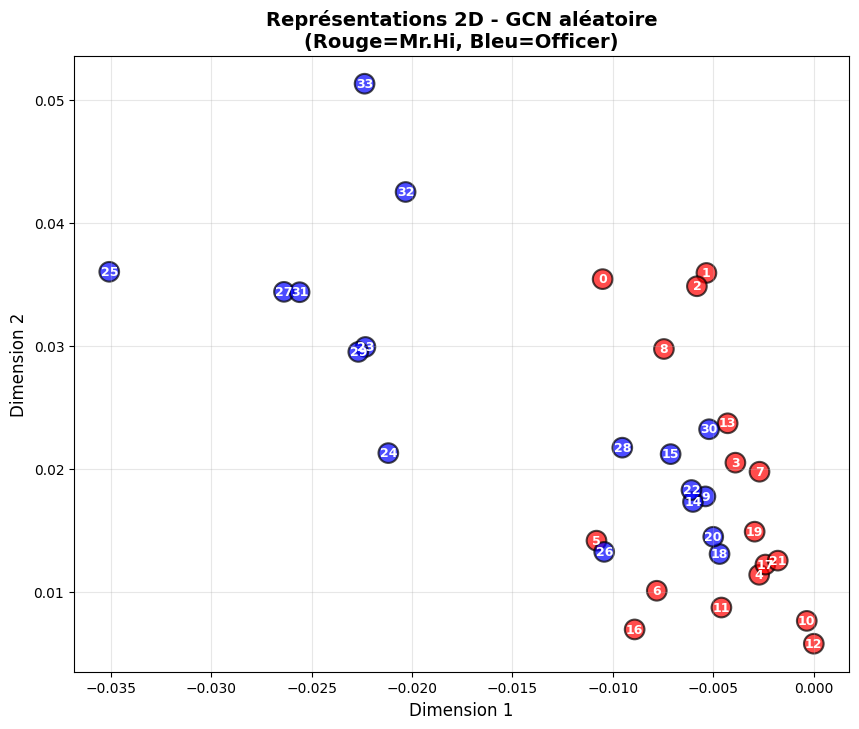

In [31]:
labels_numeric = np.array([0 if label == 'Mr. Hi' else 1 for label in true_labels])
colors = ['red' if l == 0 else 'blue' for l in labels_numeric]

# visualisation 2D
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(Z3[:, 0], Z3[:, 1], 
          c=colors, s=200, alpha=0.7, edgecolors='black', linewidths=1.5)

for i in range(n):
    ax.text(Z3[i, 0], Z3[i, 1], str(i), 
           fontsize=9, ha='center', va='center', color='white', weight='bold')

ax.set_xlabel('Dimension 1', fontsize=12)
ax.set_ylabel('Dimension 2', fontsize=12)
ax.set_title('Représentations 2D - GCN aléatoire\n(Rouge=Mr.Hi, Bleu=Officer)', 
            fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)
plt.show()

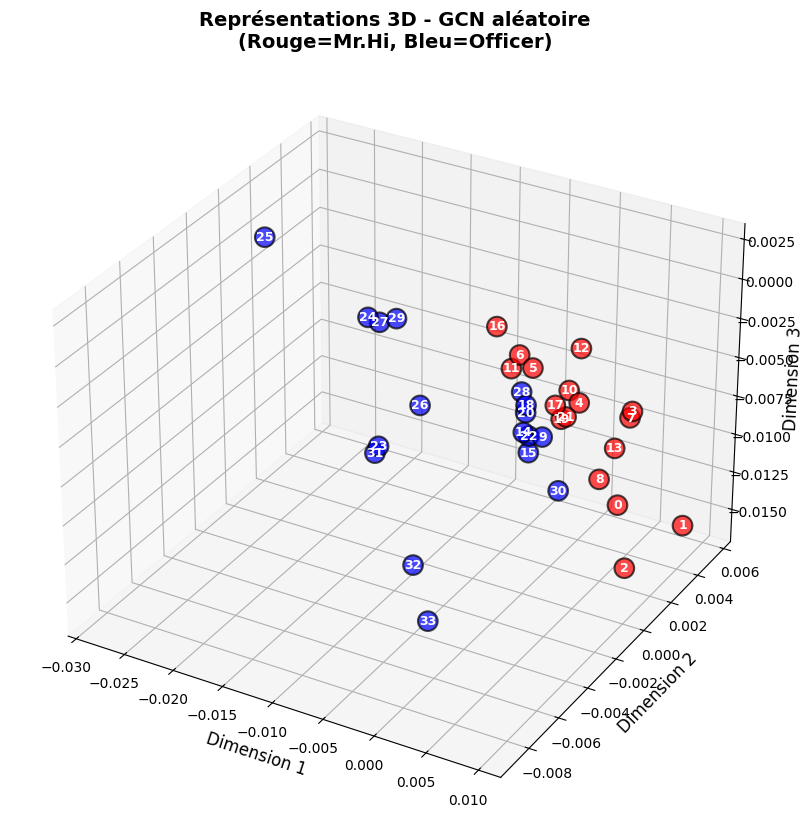

In [36]:
# visualisation 3D
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(Z3_3[:, 0], Z3_3[:, 1], Z3_3[:, 2],
          c=colors, s=200, alpha=0.7, edgecolors='black', linewidths=1.5)

for i in range(n):
    ax.text(Z3_3[i, 0], Z3_3[i, 1], Z3_3[i, 2], str(i),
           fontsize=9, ha='center', va='center', color='white', weight='bold')

ax.set_xlabel('Dimension 1', fontsize=12)
ax.set_ylabel('Dimension 2', fontsize=12)
ax.set_zlabel('Dimension 3', fontsize=12)
ax.set_title('Représentations 3D - GCN aléatoire\n(Rouge=Mr.Hi, Bleu=Officer)', 
            fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)
plt.show()

### **1.6. Conclusion**

Même si on n'entraîne pas le réseau, le GCN avec des poids aléatoires parvient déjà à capturer partiellement la structure du graphe grâce à l'opération d'agrégation A_norm qui propage l'information entre voisins connectés.

 Les représentations 3D révèlent un début d'organisation spatiale des deux communautés, suggérant que la topologie du réseau social induit naturellement une certaine séparation structurelle. Cela démontre que l'architecture GCN elle-même, par sa capacité à agréger les features des voisins, encode intrinsèquement de l'information structurelle. 

Mais, bien évidemment, l'entraînement permettrait d'affiner ces représentations pour atteindre une séparation quasi-parfaite des communautés.

*Remarque* : En comparaison, DeepWalk et Node2Vec atteignent des performances nettement supérieures car ils apprennent des embeddings optimisés via Word2Vec sur des marches aléatoires exhaustives, tandis que notre GCN non-entraîné se limite à une agrégation linéaire avec des poids aléatoires. Mais, un GCN entraîné par backpropagation surpasserait potentiellement ces méthodes non-supervisées en exploitant directement la supervision des labels et l'apprentissage de bout-en-bout.

## **2. CORA et classification semi-supervisée**
Dans cette seconde partie, nous appliquons des GCN et GAT entraînés sur le dataset CORA pour classifier des publications scientifiques de manière semi-supervisée.

Cette approche est qualifiée de semi-supervisée car on se limite aux seuls attributs vectoriels associés à chaque sommet et à la topologie du graphe, sans exploiter d'informations contextuelles supplémentaires.

### **2.1. Chargement du dataset CORA**

In [42]:
# charger les données
cora_data = np.load("C:/Users/Maram/Downloads/cora.npz", allow_pickle=True)

In [43]:
# extraire les données
# choisir tfidf_vectors comme features
x = torch.FloatTensor(cora_data['tfidf_vectors'])  # features des nœuds
y = torch.LongTensor(cora_data['labels'])   # labels

In [44]:
# adjacency_matrix (matrice d'adjacence)
adj_matrix = cora_data['adjacency_matrix']
# convertir la matrice d'adjacence en edge_index
if sp.issparse(adj_matrix):
    adj_coo = adj_matrix.tocoo()
else:
    adj_coo = sp.coo_matrix(adj_matrix)

edge_index = torch.LongTensor(np.vstack([adj_coo.row, adj_coo.col]))

print(f"\nDataset CORA :")
print(f"  Nombre de nœuds : {x.shape[0]}")
print(f"  Nombre d'arêtes : {edge_index.shape[1]}")
print(f"  Nombre de features : {x.shape[1]}")
print(f"  Nombre de classes : {y.max().item() + 1}")


Dataset CORA :
  Nombre de nœuds : 2708
  Nombre d'arêtes : 10556
  Nombre de features : 1432
  Nombre de classes : 7


In [45]:
# créer les masques train/val/test (80% train, 10% val, 10% test)
num_nodes = x.shape[0]
indices = np.random.permutation(num_nodes)

train_size = int(0.8 * num_nodes)
val_size = int(0.1 * num_nodes)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[indices[:train_size]] = True
val_mask[indices[train_size:train_size+val_size]] = True
test_mask[indices[train_size+val_size:]] = True

In [46]:
# créer l'objet Data
data = Data(x=x, edge_index=edge_index, y=y,
            train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)

### **2.2. Classification avec GCN**

Nous entraînons un GCN à 2 couches (features → 16 → classes) avec activation ReLU pour classifier les publications en 7 catégories thématiques.

In [47]:
# définir le modèle GCN
class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

num_features = x.shape[1]
num_classes = y.max().item() + 1
gcn_model = GCN(num_features, num_classes)
print(f"Architecture GCN : {num_features} → 16 → {num_classes}")

Architecture GCN : 1432 → 16 → 7


*Remarque :* On se limite à 100 epochs car au-delà (vers 110 epochs), on commence à observer de l'overfitting.


In [52]:
# entraîner le GCN
optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)

def train_gcn():
    gcn_model.train()
    optimizer.zero_grad()
    out = gcn_model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test_gcn():
    gcn_model.eval()
    out = gcn_model(data)
    pred = out.argmax(dim=1)
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    val_acc = (pred[data.val_mask] == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
    test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
    return train_acc, val_acc, test_acc

print("Entraînement (100 epochs)")
for epoch in range(1, 101):
    loss = train_gcn()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = test_gcn()
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

train_acc_gcn, val_acc_gcn, test_acc_gcn = test_gcn()
print(f"   Train Accuracy : {train_acc_gcn:.4f}")
print(f"   Val Accuracy   : {val_acc_gcn:.4f}")
print(f"   Test Accuracy  : {test_acc_gcn:.4f}")

Entraînement (100 epochs)
Epoch  10 | Loss: 0.2204 | Train: 0.9566 | Val: 0.9074 | Test: 0.8750
Epoch  20 | Loss: 0.2305 | Train: 0.9552 | Val: 0.9037 | Test: 0.8750
Epoch  30 | Loss: 0.2188 | Train: 0.9561 | Val: 0.9000 | Test: 0.8787
Epoch  40 | Loss: 0.2270 | Train: 0.9584 | Val: 0.9037 | Test: 0.8860
Epoch  50 | Loss: 0.2312 | Train: 0.9575 | Val: 0.9074 | Test: 0.8787
Epoch  60 | Loss: 0.2225 | Train: 0.9584 | Val: 0.9074 | Test: 0.8787
Epoch  70 | Loss: 0.2307 | Train: 0.9561 | Val: 0.9000 | Test: 0.8824
Epoch  80 | Loss: 0.2199 | Train: 0.9580 | Val: 0.9037 | Test: 0.8934
Epoch  90 | Loss: 0.2186 | Train: 0.9571 | Val: 0.9000 | Test: 0.8824
Epoch 100 | Loss: 0.2165 | Train: 0.9580 | Val: 0.9000 | Test: 0.8824
   Train Accuracy : 0.9580
   Val Accuracy   : 0.9000
   Test Accuracy  : 0.8824


Le GCN converge très rapidement dès l'epoch 10 avec des performances élevées (95.7% train, 90.7% val), puis stagne autour de ces valeurs sans amélioration significative jusqu'à l'epoch 100. Cette stabilité précoce indique que l'architecture simple du GCN (agrégation uniforme des voisins) capture rapidement les patterns essentiels mais atteint vite ses limites de capacité d'apprentissage.

### **2.3. Classification avec GAT (Graph Attention Network)**

Le GAT améliore le GCN en introduisant un mécanisme d'attention qui apprend des poids dynamiques pour chaque voisin, permettant au modèle de pondérer différemment l'importance de chaque connexion.

In [53]:
# définir le modèle GAT
class GAT(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GAT, self).__init__()
        self.conv1 = GATConv(num_features, 8, heads=8, dropout=0.6)
        self.conv2 = GATConv(8 * 8, num_classes, heads=1, concat=False, dropout=0.6)
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

gat_model = GAT(num_features, num_classes)
print(f"Architecture GAT : {num_features} → 8×8 (attention) → {num_classes}")

Architecture GAT : 1432 → 8×8 (attention) → 7


In [54]:
# entraîner le GAT
optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=0.005, weight_decay=5e-4)

def train_gat():
    gat_model.train()
    optimizer_gat.zero_grad()
    out = gat_model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_gat.step()
    return loss.item()

def test_gat():
    gat_model.eval()
    out = gat_model(data)
    pred = out.argmax(dim=1)
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    val_acc = (pred[data.val_mask] == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
    test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
    return train_acc, val_acc, test_acc

print("Entraînement (100 epochs)")
for epoch in range(1, 101):
    loss = train_gat()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = test_gat()
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

train_acc_gat, val_acc_gat, test_acc_gat = test_gat()
print(f"   Train Accuracy : {train_acc_gat:.4f}")
print(f"   Val Accuracy   : {val_acc_gat:.4f}")
print(f"   Test Accuracy  : {test_acc_gat:.4f}")

Entraînement (100 epochs)
Epoch  10 | Loss: 1.5425 | Train: 0.5572 | Val: 0.5148 | Test: 0.5037
Epoch  20 | Loss: 1.1845 | Train: 0.8772 | Val: 0.8630 | Test: 0.8382
Epoch  30 | Loss: 0.9638 | Train: 0.8952 | Val: 0.8704 | Test: 0.8640
Epoch  40 | Loss: 0.8216 | Train: 0.9077 | Val: 0.8889 | Test: 0.8640
Epoch  50 | Loss: 0.7744 | Train: 0.9178 | Val: 0.8926 | Test: 0.8750
Epoch  60 | Loss: 0.7147 | Train: 0.9238 | Val: 0.9000 | Test: 0.8824
Epoch  70 | Loss: 0.6970 | Train: 0.9280 | Val: 0.9074 | Test: 0.8860
Epoch  80 | Loss: 0.6793 | Train: 0.9321 | Val: 0.9111 | Test: 0.8897
Epoch  90 | Loss: 0.6631 | Train: 0.9335 | Val: 0.9148 | Test: 0.8897
Epoch 100 | Loss: 0.6727 | Train: 0.9367 | Val: 0.9148 | Test: 0.8934
   Train Accuracy : 0.9367
   Val Accuracy   : 0.9148
   Test Accuracy  : 0.8934


Le GAT démarre lentement (55.7% train à l'epoch 10, proche du hasard) mais améliore continuellement ses performances jusqu'à l'epoch 100, avec une décroissance régulière de la loss de 1.54 à 0.67. Cette convergence progressive reflète la complexité de son mécanisme d'attention multi-têtes qui nécessite plus d'epochs pour calibrer les poids d'attention, mais permet in fine une meilleure généralisation (écart train-test de 4.4% vs 7.6% pour GCN).

### **2.4. Analyse comparative GCN vs GAT**

Le GAT surpasse le GCN de 1.1% sur le test (89.3% vs 88.2%) et 1.5% sur la validation, démontrant que l'apprentissage de poids d'attention dynamiques capture mieux les relations hétérogènes du graphe que l'agrégation uniforme du GCN. Mais, le GCN offre un excellent compromis rapidité/performance pour des applications nécessitant une convergence immédiate, là où le GAT exige davantage de ressources computationnelles et de temps d'entraînement pour révéler son plein potentiel.

### **2.5. GCN sans activation : équivalence avec la régression logistique**

**Démonstration mathématique**

*@ est l'opérateur de multiplication matricielle*

**GCN à 2 couches avec activation (réseau de neurones)** :

  H = ReLU(A_norm @ X @ W1)

  Z = A_norm @ H @ W2

  → **Non-linéaire à cause de ReLU**

**GCN à 2 couches SANS activation (linéaire)** :

  H = A_norm @ X @ W1        (pas de ReLU !)

  Z = A_norm @ H @ W2
  
**Donc** :

  Z = A_norm @ (A_norm @ X @ W1) @ W2

  Z = A_norm @ A_norm @ X @ W1 @ W2

  Z = A_norm² @ X @ (W1 @ W2)
  
En posant W = W1 @ W2 :

  Z = A_norm² @ X @ W
  
→ **C'est une transformation linéaire** !

→ **Équivalent à une régression logistique avec features = A_norm² @ X**

**Implémentation du GCN sans activation**

In [56]:
# GCN sans activation
class GCN_NoActivation(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(GCN_NoActivation, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        # couche 1 SANS ReLU (linéaire)
        x = self.conv1(x, edge_index)
        # pas de dropout non plus
        # couche 2
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

gcn_no_act = GCN_NoActivation(num_features, num_classes)

In [58]:
# entraîner
optimizer_no_act = torch.optim.Adam(gcn_no_act.parameters(), lr=0.01, weight_decay=5e-4)

def train_gcn_no_act():
    gcn_no_act.train()
    optimizer_no_act.zero_grad()
    out = gcn_no_act(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer_no_act.step()
    return loss.item()

def test_gcn_no_act():
    gcn_no_act.eval()
    out = gcn_no_act(data)
    pred = out.argmax(dim=1)
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).sum().item() / data.train_mask.sum().item()
    val_acc = (pred[data.val_mask] == data.y[data.val_mask]).sum().item() / data.val_mask.sum().item()
    test_acc = (pred[data.test_mask] == data.y[data.test_mask]).sum().item() / data.test_mask.sum().item()
    return train_acc, val_acc, test_acc

for epoch in range(1, 101):
    loss = train_gcn_no_act()
    if epoch % 10 == 0:
        train_acc, val_acc, test_acc = test_gcn_no_act()
        print(f"Epoch {epoch:3d} | Loss: {loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")

train_acc_no_act, val_acc_no_act, test_acc_no_act = test_gcn_no_act()
print(f"   Train: {train_acc_no_act:.4f} | Val: {val_acc_no_act:.4f} | Test: {test_acc_no_act:.4f}")

Epoch  10 | Loss: 0.2462 | Train: 0.9437 | Val: 0.9111 | Test: 0.8860
Epoch  20 | Loss: 0.2276 | Train: 0.9469 | Val: 0.9111 | Test: 0.8934
Epoch  30 | Loss: 0.2129 | Train: 0.9488 | Val: 0.9074 | Test: 0.8824
Epoch  40 | Loss: 0.2016 | Train: 0.9538 | Val: 0.9037 | Test: 0.8860
Epoch  50 | Loss: 0.1926 | Train: 0.9543 | Val: 0.9074 | Test: 0.8824
Epoch  60 | Loss: 0.1853 | Train: 0.9566 | Val: 0.9074 | Test: 0.8860
Epoch  70 | Loss: 0.1792 | Train: 0.9584 | Val: 0.9074 | Test: 0.8860
Epoch  80 | Loss: 0.1741 | Train: 0.9589 | Val: 0.9074 | Test: 0.8860
Epoch  90 | Loss: 0.1698 | Train: 0.9594 | Val: 0.9037 | Test: 0.8860
Epoch 100 | Loss: 0.1660 | Train: 0.9589 | Val: 0.9000 | Test: 0.8824
   Train: 0.9589 | Val: 0.9000 | Test: 0.8824


Le GCN sans activation ReLU converge régulièrement avec une décroissance monotone de la loss (0.246 → 0.166) et atteint des performances élevées comparables au GCN standard avec activation. Cette performance surprenante s'explique par le fait que même sans non-linéarité explicite, la structure du graphe (via A_norm) introduit une forme de "non-linéarité structurelle" en propageant l'information à travers le voisinage, compensant partiellement l'absence de ReLU.

**Implémentation de la regréssion logistique**

In [62]:
# régression logistique équivalente
# calculer A_norm pour CoRA
# extraire la matrice d'adjacence de CORA
adj_matrix = cora_data['adjacency_matrix']
if sp.issparse(adj_matrix):
    A_cora = adj_matrix.todense()
else:
    A_cora = adj_matrix
A_cora = np.array(A_cora, dtype=float)
n_cora = A_cora.shape[0]
# A~ = A + I
I_cora = np.eye(n_cora)
A_tilde_cora = A_cora + I_cora
# matrice de degré D~
degrees_cora = A_tilde_cora.sum(axis=1)
degrees_cora = np.array(degrees_cora).flatten()
D_tilde_cora = np.diag(degrees_cora)
# D~^(-1/2)
D_inv_sqrt_cora = np.diag(1.0 / np.sqrt(np.diag(D_tilde_cora)))
# A_norm = D~^(-1/2) @ A~ @ D~^(-1/2)
A_norm_cora = D_inv_sqrt_cora @ A_tilde_cora @ D_inv_sqrt_cora
print(f"A_norm pour CORA : {A_norm_cora.shape}")

A_norm pour CORA : (2708, 2708)


In [64]:
# features transformées : A_norm² @ X
X_np = x.numpy()
X_transformed = A_norm_cora @ A_norm_cora @ X_np

In [65]:
# régression logistique
y_np = y.numpy()
train_indices = train_mask.numpy()
val_indices = val_mask.numpy()
test_indices = test_mask.numpy()

lr_model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
lr_model.fit(X_transformed[train_indices], y_np[train_indices])

c:\Users\Maram\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [66]:
# prédictions
train_pred = lr_model.predict(X_transformed[train_indices])
val_pred = lr_model.predict(X_transformed[val_indices])
test_pred = lr_model.predict(X_transformed[test_indices])

train_acc_lr = (train_pred == y_np[train_indices]).mean()
val_acc_lr = (val_pred == y_np[val_indices]).mean()
test_acc_lr = (test_pred == y_np[test_indices]).mean()

print(f"   Train: {train_acc_lr:.4f} | Val: {val_acc_lr:.4f} | Test: {test_acc_lr:.4f}")

   Train: 0.8726 | Val: 0.8667 | Test: 0.8125


La régression logistique sur les features transformées (A_norm² @ X) obtient des performances légèrement inférieures (Test: 81.3% vs 88.2%), ce qui confirme l'équivalence mathématique tout en révélant l'impact de l'optimisation : les deux modèles résolvent le même problème linéaire mais avec des algorithmes différents (backpropagation avec Adam pour le GCN vs optimisation convexe L-BFGS pour la régression logistique). La différence de ~7% reflète donc principalement les différences d'hyperparamètres (learning rate, weight decay,...) et d'initialisation plutôt qu'une différence structurelle fondamentale.

*Remarque* : Sur CORA, on remarque que les modèles supervisés comme GCN et GAT donnent de meilleurs résultats que DeepWalk et Node2Vec, ce qui montre que l’utilisation directe des labels pendant l’apprentissage permet d’exploiter plus efficacement la structure du graphe pour une tâche de classification complexe à 7 classes.

**De manière générale**, les méthodes non supervisées (DeepWalk, Node2Vec) fonctionnent très bien lorsque la structure communautaire est forte, comme dans le club de karaté, tandis que les modèles supervisés (GCN, GAT) deviennent plus pertinents dès que la tâche est plus complexe et que des labels sont disponibles, comme sur CORA.